In [2]:
# load the files
from google.colab import drive
drive.mount('/content/drive')

# load the QAs
import json
manual_QAs_json_path = "/content/drive/MyDrive/Haystack/Dataset/manual_QAs.json"
with open(manual_QAs_json_path, "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

# load the manual
file_path = "/content/drive/MyDrive/Haystack/Dataset/manual.json"
import json
with open(file_path, "r", encoding="utf-8") as file:
  manual = json.load(file)
contexts = [document["context"] for document in manual]
titles = [document["title"] for document in manual]
pages = [document["page"] for document in manual]

# load the results
names = ["last", "all", "rewrite"]
manual_results = {}
for name1 in names:
  for name2 in names:
    json_path = f"""/content/drive/MyDrive/Haystack/Result/important_results/result_{name1}_{name2}.json"""
    with open(json_path, "r", encoding="utf-8") as file:
      manual_results[f"{name1}_{name2}"] = json.load(file)

# load the evaluations
json_path = f"/content/drive/MyDrive/Haystack/Result/evaluations/manual_evaluations.json"
with open(json_path, "r", encoding="utf-8") as file:
  manual_evaluations = json.load(file)

# manual_QAs, manual, contexts, titles, pages, manual_results, manual_evaluations

Mounted at /content/drive


In [3]:
# showing the manual_evaluations
print(manual_evaluations.keys())
print(manual_evaluations['last_last'].keys())
print(manual_evaluations['last_last']['LDS'].keys())
print(manual_evaluations['last_last']['LDS']['top_k=3'].keys())
print(manual_evaluations['last_last']['LDS']['top_k=3']['retrieval'][0].keys())
print(manual_evaluations['last_last']['LDS']['top_k=3']['retrieval'][0]['F1s'])

dict_keys(['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite'])
dict_keys(['LDS', 'ESS', 'RNS'])
dict_keys(['top_k=1', 'top_k=3', 'top_k=5', 'top_k=10'])
dict_keys(['retrieval', 'response'])
dict_keys(['Ps', 'Rs', 'F1s'])
[[0.8562195897102356, 0.8587971329689026, 0.9999998807907104], [0.853908121585846, 0.8724514842033386, 0.8472336530685425], [0.865380585193634, 0.8379681706428528, 0.9999998807907104], [0.8301771283149719, 0.8443315029144287, 0.8396181464195251], [1.0, 0.8342236280441284, 0.814649224281311], [0.8534682989120483, 0.8220451474189758, 0.8453710079193115], [0.8487529158592224, 0.853088915348053, 0.8443315029144287], [0.8301770687103271, 0.8526404500007629, 1.0], [0.8439739942550659, 0.8028115034103394, 0.8254881501197815], [0.8413432836532593, 0.8393248319625854, 0.8412869572639465], [0.8388203978538513, 0.8347758054733276, 0.8344753384590149], [0.8344753384590149, 0.8339464664459229, 0.825310707

In [4]:
# convert manual_evaluations into manual_analysis_df
import pandas as pd
import numpy as np

methods = ['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite']
qas_types = ['LDS', 'ESS', 'RNS']
top_ks = ['top_k=1', 'top_k=3', 'top_k=5', 'top_k=10']
aspects = ['retrieval', 'response']
scores = ['Ps', 'Rs', 'F1s']

manual_analysis_dic = {
    "method": [],
    "qas_type": [],
    "top_k": [],
    "conv_ID": [],
    "query_ID": [],
    "precision of retrieval": [],
    "recall of retrieval": [],
    "F1 score of retrieval": [],
    "precision of response": [],
    "recall of response": [],
    "F1 score of response": []
}

for method in methods:
  for qas_type in qas_types:
    for top_k in top_ks:
      for conv_ID in range(40):
        # check if the score is avaliable or an error
        if manual_evaluations[method][qas_type][top_k]['retrieval'][conv_ID] != "Error":
          # record the queries_length
          queries_length = len(manual_evaluations[method][qas_type][top_k]['retrieval'][conv_ID]["F1s"])
          # record each query one by one
          for query_ID in range(queries_length):
            # append the normal information
            manual_analysis_dic["method"].append(method)
            manual_analysis_dic["qas_type"].append(qas_type)
            manual_analysis_dic["top_k"].append(top_k)
            manual_analysis_dic["conv_ID"].append(conv_ID)
            manual_analysis_dic["query_ID"].append(query_ID)

            # append the max, min, mean scores for retrieval
            precision_of_retrieval = manual_evaluations[method][qas_type][top_k]['retrieval'][conv_ID]['Ps'][query_ID]
            recall_of_retrieval = manual_evaluations[method][qas_type][top_k]['retrieval'][conv_ID]['Rs'][query_ID]
            F1_score_of_retrieval = manual_evaluations[method][qas_type][top_k]['retrieval'][conv_ID]['F1s'][query_ID]
            retrieval_scores = lambda lst: [max(lst), min(lst), sum(lst)/len(lst)]
            manual_analysis_dic["precision of retrieval"].append(retrieval_scores(precision_of_retrieval))
            manual_analysis_dic["recall of retrieval"].append(retrieval_scores(recall_of_retrieval))
            manual_analysis_dic["F1 score of retrieval"].append(retrieval_scores(F1_score_of_retrieval))

            # append the scores for response
            precision_of_response = manual_evaluations[method][qas_type][top_k]['response'][conv_ID]['Ps'][query_ID]
            recall_of_response = manual_evaluations[method][qas_type][top_k]['response'][conv_ID]['Rs'][query_ID]
            F1_score_of_response = manual_evaluations[method][qas_type][top_k]['response'][conv_ID]['F1s'][query_ID]
            manual_analysis_dic["precision of response"].append(precision_of_response)
            manual_analysis_dic["recall of response"].append(recall_of_response)
            manual_analysis_dic["F1 score of response"].append(F1_score_of_response)

# save the df
manual_analysis_df = pd.DataFrame(manual_analysis_dic)
manual_analysis_df.to_excel("/content/drive/MyDrive/Haystack/Result/manual_analysis_df.json.xlsx", index=False)

In [5]:
# analysis the effect of methods

# lambda functions for retrieval scores
sum_of_retrieval_scores = lambda method, score, index, queries_min_length: sum(
    [scores[index] for scores in manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["query_ID"].astype(int) >= queries_min_length - 1)
    ][score]]
)

len_of_scores = lambda method, queries_min_length: len(
    manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["query_ID"].astype(int) >= queries_min_length - 1)
    ]
)

mean_of_retrieval_scores = lambda method, score, index, queries_min_length=1: sum_of_retrieval_scores(method, score, index, queries_min_length) / len_of_scores(method, queries_min_length)

# lambda functions for response scores
sum_of_response_scores = lambda method, score, queries_min_length: sum(
    manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["query_ID"].astype(int) >= queries_min_length - 1)
    ][score]
)

mean_of_response_scores = lambda method, score, queries_min_length=1: sum_of_response_scores(method, score, queries_min_length) / len_of_scores(method, queries_min_length)

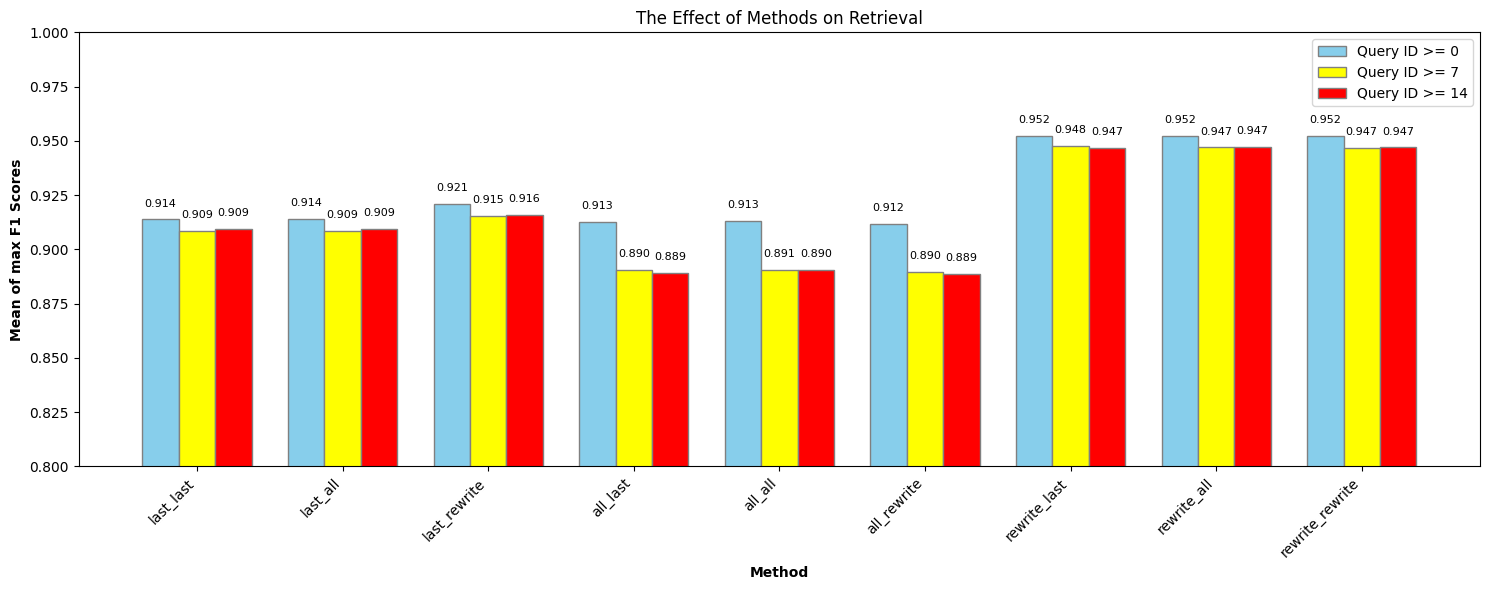

In [6]:
# @title
# The Effect of Methods on Retrieval
methods = ['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite']
retrieval_scores = {
    "query_ID >= 0": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0) for method in methods],
    "query_ID >= 7": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0, 7) for method in methods],
    "query_ID >= 14": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0, 14) for method in methods],
}

import numpy as np
import matplotlib.pyplot as plt

# --- Bar Chart Customization ---
# Define the number of groups and bars per group
n_groups = len(methods)
n_bars = len(retrieval_scores)
# Set the width of the bars
bar_width = 0.25
# Set the positions for the groups on the x-axis
index = np.arange(n_groups)
# Define positions for each set of bars (Grouped Bar Calculation)
r1 = index
r2 = index + bar_width
r3 = index + 2 * bar_width

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plotting the three sets of bars
bar1 = plt.bar(r1, retrieval_scores["query_ID >= 0"], color='skyblue', width=bar_width, edgecolor='grey', label='Query ID >= 0')
bar2 = plt.bar(r2, retrieval_scores["query_ID >= 7"], color='yellow', width=bar_width, edgecolor='grey', label='Query ID >= 7')
bar3 = plt.bar(r3, retrieval_scores["query_ID >= 14"], color='red', width=bar_width, edgecolor='grey', label='Query ID >= 14')

# --- Adding Labels and Text ---
# Function to add text labels on top of the bars
def add_labels(rects, scores):
    for rect, score in zip(rects, scores):
        height = rect.get_height()
        # Add 0.005 for a small offset above the bar
        plt.text(rect.get_x() + rect.get_width() / 2., height + 0.005,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bar1, retrieval_scores["query_ID >= 0"])
add_labels(bar2, retrieval_scores["query_ID >= 7"])
add_labels(bar3, retrieval_scores["query_ID >= 14"])

# --- Final Adjustments ---
plt.title('The Effect of Methods on Retrieval')
plt.xlabel('Method', fontweight='bold')
plt.ylabel('Mean of max F1 Scores', fontweight='bold')
# Set x-axis ticks to be in the middle of the bar groups
plt.xticks(index + bar_width, methods, rotation=45, ha='right')
# Adjust the starting value of y
plt.ylim(0.8, 1.00) # Increased max y-limit to accommodate labels
# Add the legend at the top right (loc='upper right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

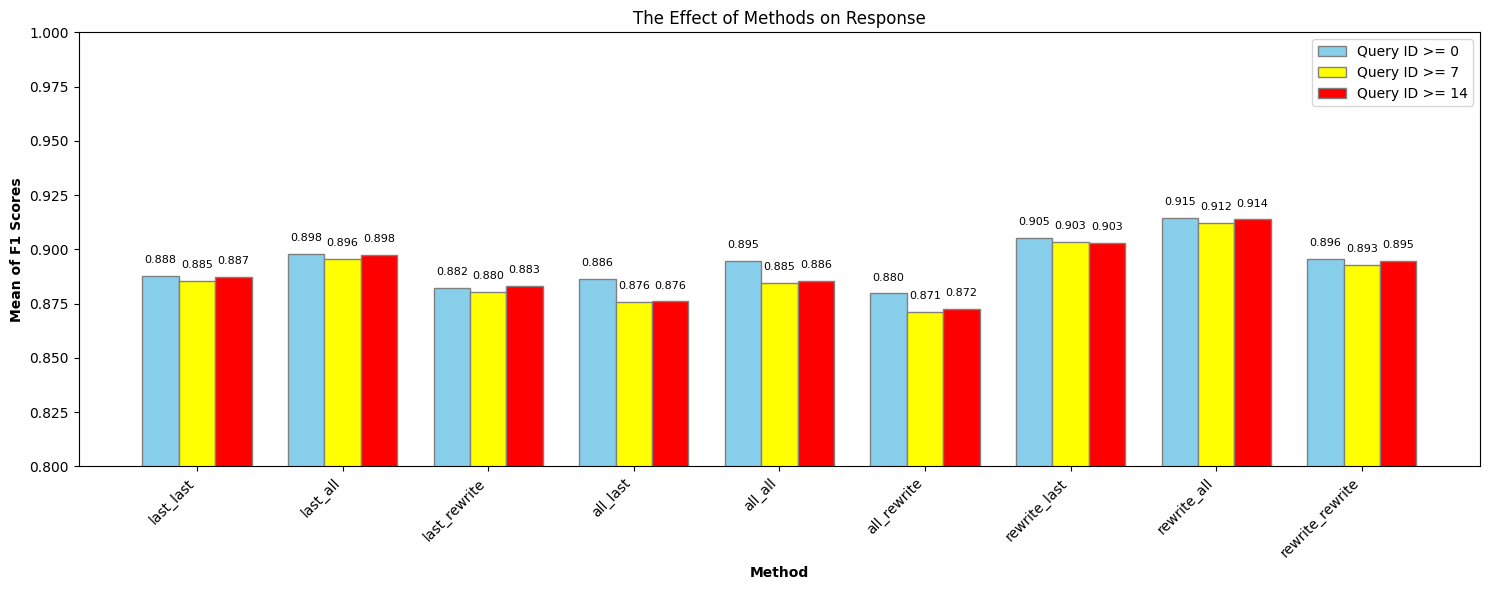

In [7]:
# @title
# The Effect of Methods on Response
methods = ['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite']
response_scores = {
    "query_ID >= 0": [mean_of_response_scores(method, "F1 score of response") for method in methods],
    "query_ID >= 7": [mean_of_response_scores(method, "F1 score of response", 7) for method in methods],
    "query_ID >= 14": [mean_of_response_scores(method, "F1 score of response", 14) for method in methods],
}

import numpy as np
import matplotlib.pyplot as plt

# --- Bar Chart Customization ---
# Define the number of groups and bars per group
n_groups = len(methods)
n_bars = len(response_scores)
# Set the width of the bars
bar_width = 0.25
# Set the positions for the groups on the x-axis
index = np.arange(n_groups)
# Define positions for each set of bars (Grouped Bar Calculation)
r1 = index
r2 = index + bar_width
r3 = index + 2 * bar_width

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plotting the three sets of bars
bar1 = plt.bar(r1, response_scores["query_ID >= 0"], color='skyblue', width=bar_width, edgecolor='grey', label='Query ID >= 0')
bar2 = plt.bar(r2, response_scores["query_ID >= 7"], color='yellow', width=bar_width, edgecolor='grey', label='Query ID >= 7')
bar3 = plt.bar(r3, response_scores["query_ID >= 14"], color='red', width=bar_width, edgecolor='grey', label='Query ID >= 14')

# --- Adding Labels and Text ---
# Function to add text labels on top of the bars
def add_labels(rects, scores):
    for rect, score in zip(rects, scores):
        height = rect.get_height()
        # Add 0.005 for a small offset above the bar
        plt.text(rect.get_x() + rect.get_width() / 2., height + 0.005,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bar1, response_scores["query_ID >= 0"])
add_labels(bar2, response_scores["query_ID >= 7"])
add_labels(bar3, response_scores["query_ID >= 14"])

# --- Final Adjustments ---
plt.title('The Effect of Methods on Response')
plt.xlabel('Method', fontweight='bold')
plt.ylabel('Mean of F1 Scores', fontweight='bold')
# Set x-axis ticks to be in the middle of the bar groups
plt.xticks(index + bar_width, methods, rotation=45, ha='right')
# Adjust the starting value of y
plt.ylim(0.8, 1.00) # Increased max y-limit to accommodate labels
# Add the legend at the top right (loc='upper right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [8]:
# analysis the effect of methods

# lambda functions for retrieval scores
sum_of_retrieval_scores = lambda method, score, index, qas_type: sum(
    [scores[index] for scores in manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["qas_type"]== qas_type)
    ][score]]
)

len_of_scores = lambda method, qas_type: len(
    manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["qas_type"]== qas_type)
    ]
)

mean_of_retrieval_scores = lambda method, score, index, qas_type: sum_of_retrieval_scores(method, score, index, qas_type) / len_of_scores(method, qas_type)

# lambda functions for response scores
sum_of_response_scores = lambda method, score, qas_type: sum(
    manual_analysis_df[
        (manual_analysis_df["method"] == method) &
        (manual_analysis_df["qas_type"]== qas_type)
    ][score]
)

mean_of_response_scores = lambda method, score, qas_type: sum_of_response_scores(method, score, qas_type) / len_of_scores(method, qas_type)

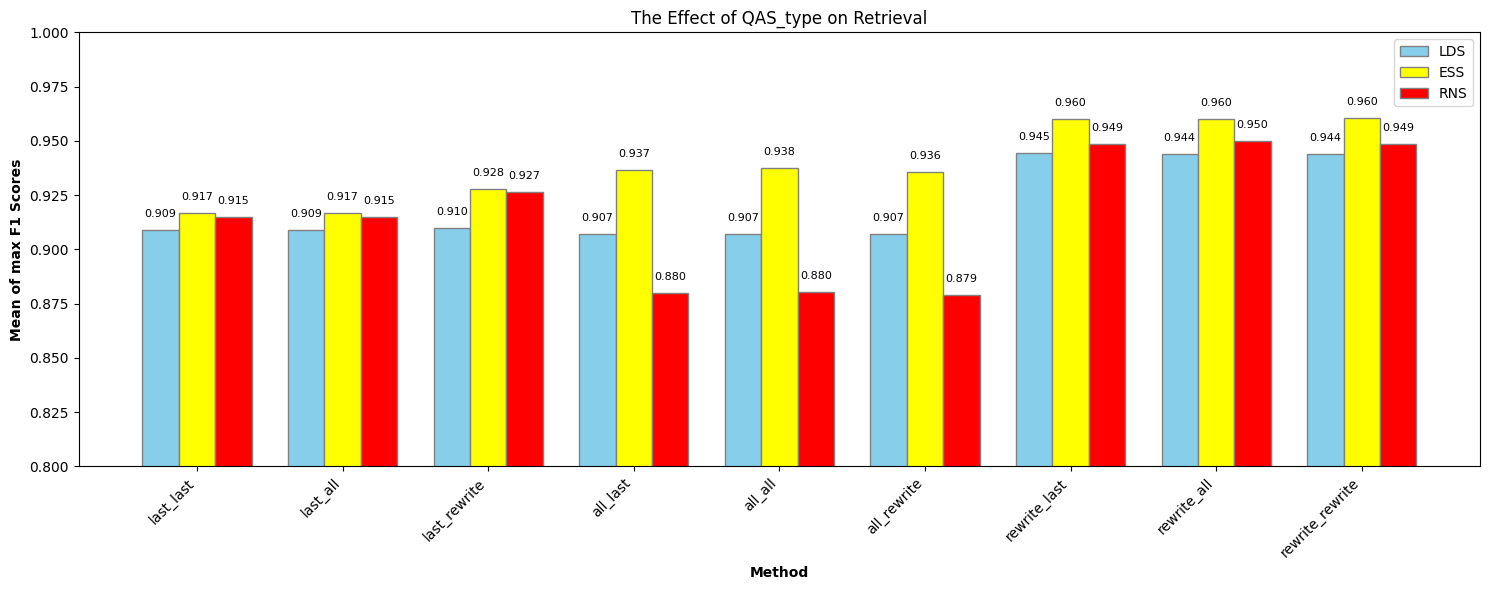

In [9]:
# @title
# The Effect of Methods on Retrieval
methods = ['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite']
retrieval_scores = {
    "LDS": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0, "LDS") for method in methods],
    "ESS": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0, "ESS") for method in methods],
    "RNS": [mean_of_retrieval_scores(method, "F1 score of retrieval", 0, "RNS") for method in methods],
}

import numpy as np
import matplotlib.pyplot as plt

# --- Bar Chart Customization ---
# Define the number of groups and bars per group
n_groups = len(methods)
n_bars = len(retrieval_scores)
# Set the width of the bars
bar_width = 0.25
# Set the positions for the groups on the x-axis
index = np.arange(n_groups)
# Define positions for each set of bars (Grouped Bar Calculation)
r1 = index
r2 = index + bar_width
r3 = index + 2 * bar_width

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plotting the three sets of bars
bar1 = plt.bar(r1, retrieval_scores["LDS"], color='skyblue', width=bar_width, edgecolor='grey', label='LDS')
bar2 = plt.bar(r2, retrieval_scores["ESS"], color='yellow', width=bar_width, edgecolor='grey', label='ESS')
bar3 = plt.bar(r3, retrieval_scores["RNS"], color='red', width=bar_width, edgecolor='grey', label='RNS')

# --- Adding Labels and Text ---
# Function to add text labels on top of the bars
def add_labels(rects, scores):
    for rect, score in zip(rects, scores):
        height = rect.get_height()
        # Add 0.005 for a small offset above the bar
        plt.text(rect.get_x() + rect.get_width() / 2., height + 0.005,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bar1, retrieval_scores["LDS"])
add_labels(bar2, retrieval_scores["ESS"])
add_labels(bar3, retrieval_scores["RNS"])

# --- Final Adjustments ---
plt.title('The Effect of QAS_type on Retrieval')
plt.xlabel('Method', fontweight='bold')
plt.ylabel('Mean of max F1 Scores', fontweight='bold')
# Set x-axis ticks to be in the middle of the bar groups
plt.xticks(index + bar_width, methods, rotation=45, ha='right')
# Adjust the starting value of y
plt.ylim(0.8, 1.00) # Increased max y-limit to accommodate labels
# Add the legend at the top right (loc='upper right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

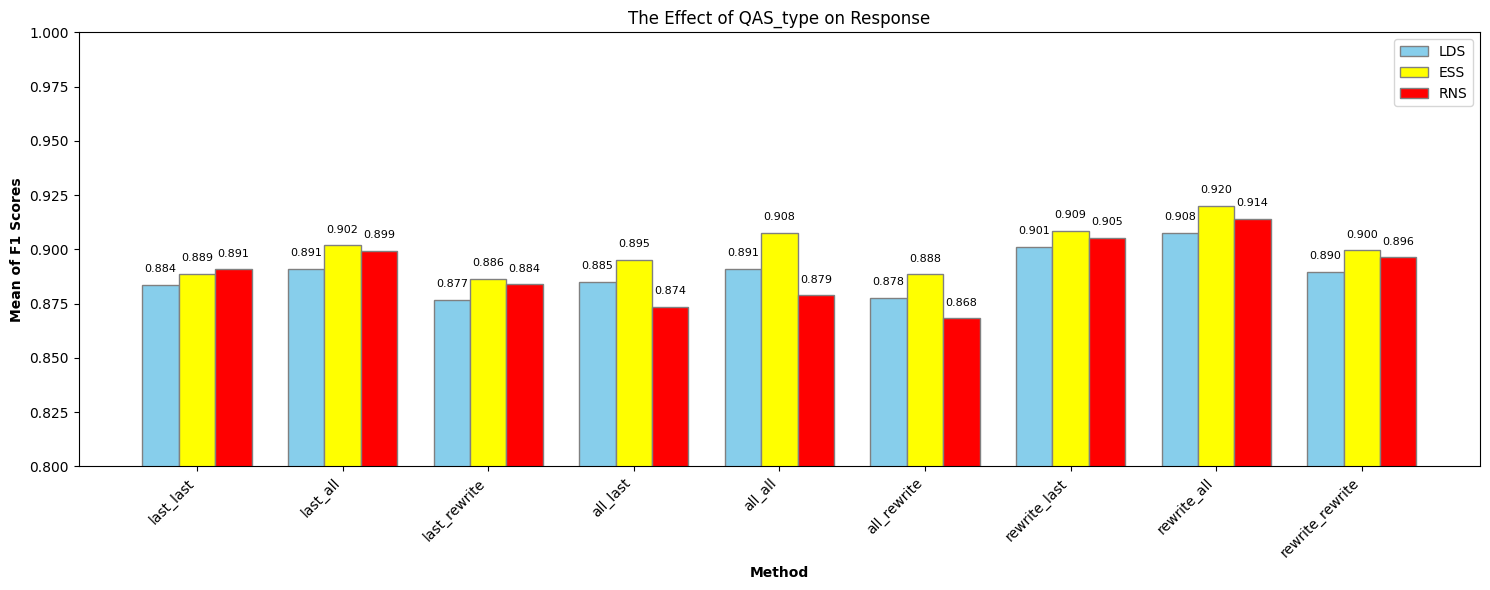

In [10]:
# @title
# The Effect of Methods on Response
methods = ['last_last', 'last_all', 'last_rewrite', 'all_last', 'all_all', 'all_rewrite', 'rewrite_last', 'rewrite_all', 'rewrite_rewrite']
response_scores = {
    "LDS": [mean_of_response_scores(method, "F1 score of response", "LDS") for method in methods],
    "ESS": [mean_of_response_scores(method, "F1 score of response", "ESS") for method in methods],
    "RNS": [mean_of_response_scores(method, "F1 score of response", "RNS") for method in methods],
}

import numpy as np
import matplotlib.pyplot as plt

# --- Bar Chart Customization ---
# Define the number of groups and bars per group
n_groups = len(methods)
n_bars = len(response_scores)
# Set the width of the bars
bar_width = 0.25
# Set the positions for the groups on the x-axis
index = np.arange(n_groups)
# Define positions for each set of bars (Grouped Bar Calculation)
r1 = index
r2 = index + bar_width
r3 = index + 2 * bar_width

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plotting the three sets of bars
bar1 = plt.bar(r1, response_scores["LDS"], color='skyblue', width=bar_width, edgecolor='grey', label='LDS')
bar2 = plt.bar(r2, response_scores["ESS"], color='yellow', width=bar_width, edgecolor='grey', label='ESS')
bar3 = plt.bar(r3, response_scores["RNS"], color='red', width=bar_width, edgecolor='grey', label='RNS')

# --- Adding Labels and Text ---
# Function to add text labels on top of the bars
def add_labels(rects, scores):
    for rect, score in zip(rects, scores):
        height = rect.get_height()
        # Add 0.005 for a small offset above the bar
        plt.text(rect.get_x() + rect.get_width() / 2., height + 0.005,
                 f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bar1, response_scores["LDS"])
add_labels(bar2, response_scores["ESS"])
add_labels(bar3, response_scores["RNS"])

# --- Final Adjustments ---
plt.title('The Effect of QAS_type on Response')
plt.xlabel('Method', fontweight='bold')
plt.ylabel('Mean of F1 Scores', fontweight='bold')
# Set x-axis ticks to be in the middle of the bar groups
plt.xticks(index + bar_width, methods, rotation=45, ha='right')
# Adjust the starting value of y
plt.ylim(0.8, 1.00) # Increased max y-limit to accommodate labels
# Add the legend at the top right (loc='upper right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
score_topk1 = sum(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=1"]["F1 score of response"])/len(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=1"]["F1 score of response"])
score_topk3 = sum(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=3"]["F1 score of response"])/len(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=3"]["F1 score of response"])
score_topk5 = sum(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=5"]["F1 score of response"])/len(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=5"]["F1 score of response"])
score_topk10 = sum(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=10"]["F1 score of response"])/len(manual_analysis_df[manual_analysis_df["top_k"] == "top_k=10"]["F1 score of response"])

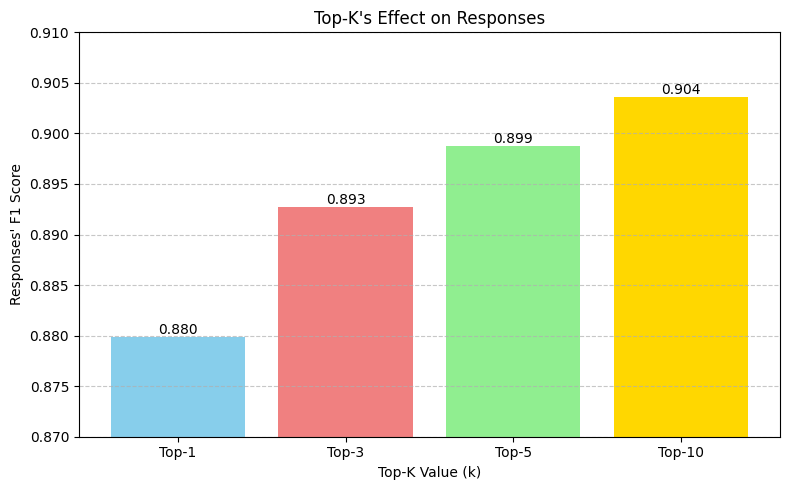

In [23]:
labels = ['Top-1', 'Top-3', 'Top-5', 'Top-10']
scores = [score_topk1, score_topk3, score_topk5, score_topk10]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
ax.set_ylabel("Responses' F1 Score")
ax.set_xlabel('Top-K Value (k)')
ax.set_title("Top-K's Effect on Responses")

# 设置Y轴范围（通常准确率在0到1之间）
ax.set_ylim(0.87, 0.91)

# 在每个柱子上方添加具体的数值
for bar in bars:
    yval = bar.get_height()
    # 格式化数值，保留三位小数
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()